In [11]:
import sys
from pathlib import Path

# Find project root dynamically
def get_project_root() -> Path:
    try:
        path = Path(__file__).resolve()
        for parent in [path] + list(path.parents):
            if (parent / "requirements.txt").exists() or (parent / "project").exists():
                return parent
    except NameError:
        pass
    path = Path.cwd().resolve()
    for parent in [path] + list(path.parents):
        if (parent / "requirements.txt").exists() or (parent / "project").exists():
            return parent
    return path

ROOT = get_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import torch.nn as nn
from torch.nn import functional as F
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# parameters
batch_size = 128          # number of sequences processed together
learning_rate = 3e-4

n_embd = 192             # embedding dimension
n_head = 6               # number of attention heads
n_layer = 6              # number of transformer blocks
dropout = 0.1            # dropout probability

# SINGLE ATTENTION HEAD
# one self-attention unit
# learns ONE type of relationship between tokens

class Head(nn.Module):

    def __init__(self, head_size):

        super().__init__()

        # key, query, value projections
        # these are learned linear transformations
        # Query : what is this token looking for?
        # Key   : what information does this token contain?
        # Value : what information should this token pass forward?
        # each token gets transformed into Q,K,V vectors

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # causal mask REMOVED

        # dropout layer - randomly removes some values during training
        # prevents overfitting
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # B = batch size
        # T = sequence length
        # C = embedding dimension

        B, T, C = x.shape

        # create key, query, value matrices
        # shape:
        # (B,T,n_embd) -> (B,T,head_size)

        k = self.key(x)       # (B,T,head_size)
        q = self.query(x)     # (B,T,head_size)
        v = self.value(x)     # (B,T,head_size)

        # attention scores
        # every token compares itself with every other token
        # transpose(-2,-1): swaps last two dimensions
        # @ = matrix multiplication
        # shape: (B,T,head_size) @ (B,head_size,T) -> (B,T,T)
        wei = q @ k.transpose(-2, -1)

        # scale scores
        # prevents values from becoming too large
        # stabilizes softmax and gradients
        wei = wei * (k.size(-1) ** -0.5)

        # convert scores to probabilities
        # softmax along last dimension
        # each row now sums to 1
        wei = F.softmax(wei, dim=-1)

        # dropout on attention probabilities
        wei = self.dropout(wei)

        # weighted aggregation of values
        # attention weights multiply value vectors
        # tokens gather information from important tokens
        # shape: (B,T,T) @ (B,T,head_size) -> (B,T,head_size)
        out = wei @ v

        return out

# BLOCK 1
# MULTI HEAD ATTENTION
# instead of using ONE attention head, transformers use MANY heads in parallel
# different heads learn different relationships
# examples:
# - one head learns punctuation
# - one learns nearby context
# - one learns long-range dependencies
# all heads see same input
# but each head has separate Q,K,V matrices

class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, head_size):

        super().__init__()

        # ModuleList:
        # special PyTorch list for storing trainable modules
        # each Head is independent

        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])

        # projection layer - learns how to combine information from all heads
        # concatenated heads are mixed together here
        # without this layer: heads would remain independent

        self.proj = nn.Linear( num_heads * head_size, n_embd)

        # dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # concatenate outputs from all heads
        out = torch.cat([h(x) for h in self.heads], dim=-1)

        # projection layer
        # mixes information from all heads
        out = self.proj(out)

        # dropout on final output features
        out = self.dropout(out)

        return out


# BLOCK 2
# FEED FORWARD NETWORK (MLP)
# attention mixes information BETWEEN tokens
# feed-forward network processes EACH token independently
# helps model learn:
# - higher level features
# - nonlinear transformations

# structure:
# Linear -> ReLU -> Linear

class FeedForward(nn.Module):

    def __init__(self, n_embd):

        super().__init__()

        # Sequential:
        # runs layers one after another automatically
        self.net = nn.Sequential(

            # expand dimension
            # transformer MLPs are usually 4x wider
            nn.Linear( n_embd, 4 * n_embd),

            # non-linearity
            # without activation functions, entire network becomes only linear algebra
            nn.ReLU(),

            # project back to original dimension
            nn.Linear(4 * n_embd, n_embd),

            # dropout
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


# TRANSFORMER BLOCK
# 1. multi-head attention
# 2. feed-forward network
# 3. layer normalization
# 4. residual connections

class Block(nn.Module):

    def __init__(self, n_embd, n_head):

        super().__init__()

        # dimensions handled by each head
        # example:
        # 128 embedding dim / 4 heads = 32 per head

        head_size = n_embd // n_head

        # multi-head self-attention
        self.sa = MultiHeadAttention(n_head, head_size)

        # feed-forward network
        self.ffwd = FeedForward(n_embd)

        # layer normalization
        # normalizes activations
        # stabilizes training
        # applied across embedding dimension

        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        # PRE-NORM TRANSFORMER
        # normalization happens before sublayer
        # modern transformers mostly use pre-norm
        # because training is more stable

        # residual connection
        # x + sublayer(x)
        # model learns "small correction to x" instead of complete transformation

        x = x + self.sa(self.ln1(x))

        # second residual connection
        x = x + self.ffwd(self.ln2(x))

        return x


# ViT MODEL

class ViT(nn.Module):

    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_chans=3,
        num_classes=10,
        n_embd=192,
        n_head=6,
        n_layer=6,
        dropout=0.1
    ):

        super().__init__()
        # Number of image patches
        # CIFAR:
        # 32x32 image
        # patch size = 4
        # patches per side = 32/4 = 8
        # total patches = 8x8 = 64

        num_patches = (img_size // patch_size) ** 2

        # PATCH EMBEDDING
        # Conv2D performs:
        # 1. patch extraction
        # 2. linear projection
        # Input:
        # (B,3,32,32)
        # Output:
        # (B,192,8,8)

        self.patch_embed = nn.Conv2d(
            in_channels=in_chans,
            out_channels=n_embd,
            kernel_size=patch_size,
            stride=patch_size
        )

        # CLS TOKEN
        # Learnable image summary token
        # Shape: (1,1,192)

        self.cls_token = nn.Parameter( torch.zeros(1, 1, n_embd))

        # POSITION EMBEDDINGS
        # +1 because CLS token also needs position
        # Shape: (1,65,192)

        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, n_embd))

        self.dropout = nn.Dropout(dropout)

        # TRANSFORMER BLOCKS

        self.blocks = nn.Sequential(
            *[
                Block(n_embd, n_head)
                for _ in range(n_layer)
            ]
        )

        self.norm = nn.LayerNorm(n_embd)

        # CLASSIFICATION HEAD
        # CLS representation -> CIFAR class logits

        self.head = nn.Linear(n_embd, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):

        B = x.shape[0]

        # PATCH EMBEDDING
        # (B,3,32,32) -> (B,192,8,8)
        x = self.patch_embed(x)

        # FLATTEN PATCH GRID
        # (B,192,8,8) -> (B,192,64)
        x = x.flatten(2)

        # TRANSFORMER FORMAT
        # (B,192,64) -> (B,64,192)
        x = x.transpose(1, 2)

        # ADD CLS TOKEN
        cls = self.cls_token.expand(B, -1, -1)

        x = torch.cat([cls, x], dim=1)

        # POSITION EMBEDDINGS
        x = x + self.pos_embed

        x = self.dropout(x)

        # TRANSFORMER BLOCKS
        x = self.blocks(x)

        x = self.norm(x)

        # TAKE CLS TOKEN
        # CLS token is at index 0

        cls_final = x[:, 0]

        # CLASSIFICATION

        logits = self.head(cls_final)

        return logits


transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(
    root=str(ROOT / 'data'),
    train=True,
    download=True, # Changed from False to True
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root=str(ROOT / 'data'),
    train=False,
    download=True, # Changed from False to True
    transform=transform_test
)

trainloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

testloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)


# model
model = ViT().to(device)


# optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []
train_accs = []
val_accs = []

# training loop
epochs = 30

for epoch in range(epochs):

    train_correct = 0
    train_total = 0

    model.train()

    running_loss = 0.0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        preds = logits.argmax(dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        loss = F.cross_entropy(
            logits,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)

    train_acc = 100 * train_correct / train_total

    train_losses.append(avg_loss)
    train_accs.append(train_acc)

    print(
        f"Epoch {epoch+1}: "
        f"Loss = {avg_loss:.4f}"
    )


    model.eval()


    val_correct = 0
    val_total = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            predictions = logits.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    val_accs.append(val_acc)


Epoch 1: Loss = 1.8488
Epoch 2: Loss = 1.4522
Epoch 3: Loss = 1.3036
Epoch 4: Loss = 1.2226
Epoch 5: Loss = 1.1631
Epoch 6: Loss = 1.1195
Epoch 7: Loss = 1.0894
Epoch 8: Loss = 1.0454
Epoch 9: Loss = 1.0227
Epoch 10: Loss = 0.9921
Epoch 11: Loss = 0.9651
Epoch 12: Loss = 0.9409
Epoch 13: Loss = 0.9141
Epoch 14: Loss = 0.8925
Epoch 15: Loss = 0.8655
Epoch 16: Loss = 0.8436
Epoch 17: Loss = 0.8232
Epoch 18: Loss = 0.8071
Epoch 19: Loss = 0.7838
Epoch 20: Loss = 0.7549
Epoch 21: Loss = 0.7360
Epoch 22: Loss = 0.7160
Epoch 23: Loss = 0.6911
Epoch 24: Loss = 0.6671
Epoch 25: Loss = 0.6393
Epoch 26: Loss = 0.6214
Epoch 27: Loss = 0.6026
Epoch 28: Loss = 0.5746
Epoch 29: Loss = 0.5575
Epoch 30: Loss = 0.5279


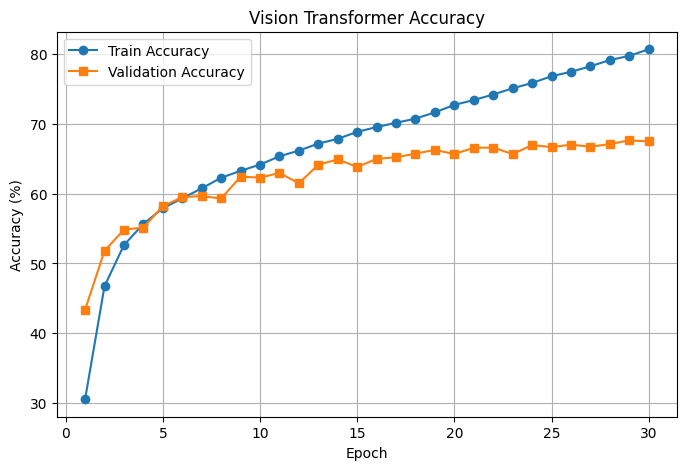

In [13]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    train_accs,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    epochs_range,
    val_accs,
    marker='s',
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Vision Transformer Accuracy')

plt.legend()
plt.grid(True)

plt.savefig(
    'vit_accuracy_curves.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [12]:
print(len(train_accs))
print(len(val_accs))

30
30
